In [ ]:
pip install -q langgraph langchain langchain-openai

In [ ]:
import os
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_ENDPOINT"]="https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"]="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"
os.environ["LANGCHAIN_PROJECT"]="AgenticAI"
os.environ["OPENAI_API_KEY"] = ""

In [ ]:
from pydantic import BaseModel, Field

class PySparkCode(BaseModel):
  pyspark_code: str = Field(
      description="Pyspark DataFrame code that satisfies the users query using a Dataframe named retail_df"
  )

In [ ]:
from typing import TypedDict, Annotated

class State(TypedDict):
  #input
  user_query: Annotated[str, "The natural language query from the user"]
  #ouput
  pyspark_code: Annotated[str, "Generated Pyspark Dataframe Code"]

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature = 0)

pyspark_llm = llm.with_structured_output(PySparkCode)

In [ ]:
from langchain.prompts import ChatPromptTemplate
pyspark_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You are a PySpark assistant. Assume a DataFrame named `retail_df` with columns:\n"
        "['order_id', 'customer_id', 'customer_name', 'product', 'category', "
        "'quantity', 'price', 'total', 'order_date', 'region'].\n"
        "Convert the user request into PySpark DataFrame code."
    )),
    ("human", "User request: {question}")
])


In [ ]:
from operator import itemgetter

def generate_pyspark(state: State) -> State:
  chain = itemgetter("question") | pyspark_prompt | pyspark_llm
  result = chain.invoke({"question": state["user_query"]})
  return {"pyspark_code": result.pyspark_code}


In [ ]:
from langgraph.graph import StateGraph, START, END

# state
builder = StateGraph(State)

# nodes
builder.add_node("generate_pyspark", generate_pyspark)

# edges
builder.add_edge(START, "generate_pyspark")
builder.add_edge("generate_pyspark", END)

# compile
code_to_pyspark_graph =  builder.compile()

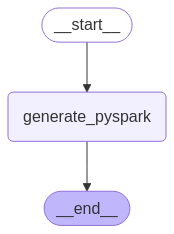

In [ ]:
from IPython.display import Image, display
display(Image(code_to_pyspark_graph.get_graph().draw_mermaid_png()))

In [ ]:
query = "Show all electronic orders where total is greater than 1000"

result = code_to_pyspark_graph.invoke({"user_query": query})

print(" Pyspark Code:\n", result["pyspark_code"])

 Pyspark Code:
 electronic_orders_df = retail_df.filter((retail_df.category == 'Electronics') & (retail_df.total > 1000))
